In [ ]:
import sys
import os
os.environ["KERAS_BACKEND"] = "torch"
sys.path.append("./src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from keras.models import load_model


from models import *
from utils import *
# -------------------
# CONFIG
# -------------------
MODEL_DIR = "models"
DATA_ROOT = "processed_data"
zip_path = ""
image_folder = "data/train_images/"
IMAGE_FOLDER = os.path.join(DATA_ROOT, "images")
LABELS_FILE = os.path.join(DATA_ROOT, "labels.csv")


Load_from_ZIP = False


CONFIG = {
    "img_size": (255, 255, 1),  # Must match the selected model
    "model_name": "deeperv3",   # 👈 change this to switch model
}

Multi_scale_patch = True if CONFIG["model_name"] == "multiscale" else False
# -------------------
# HELPERS
# -------------------
def get_model_path(config):
    model_name = config["model_name"]
    
    
    ps = config["img_size"][0]


    filename = f"{model_name}_ps{ps}.keras"
    return os.path.join(MODEL_DIR, filename)

Loading best model from: models\deeperv3_ps255.keras

--- MASS IMAGE ---
Selected image: 13eaf76f8ddd04c74b0215255afbb2e3


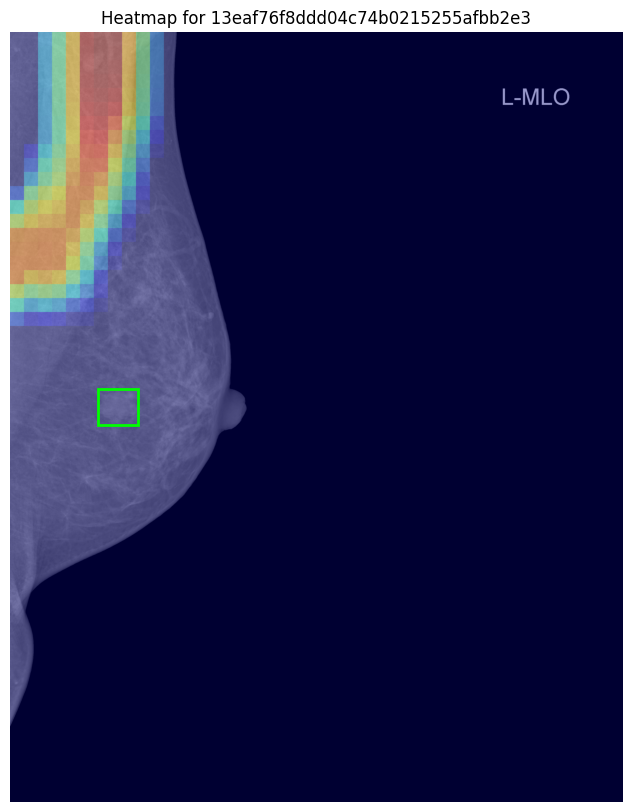


--- NO MASS IMAGE ---
Selected image: 323f8bf1926e56ec02e2bc2c5fe751da


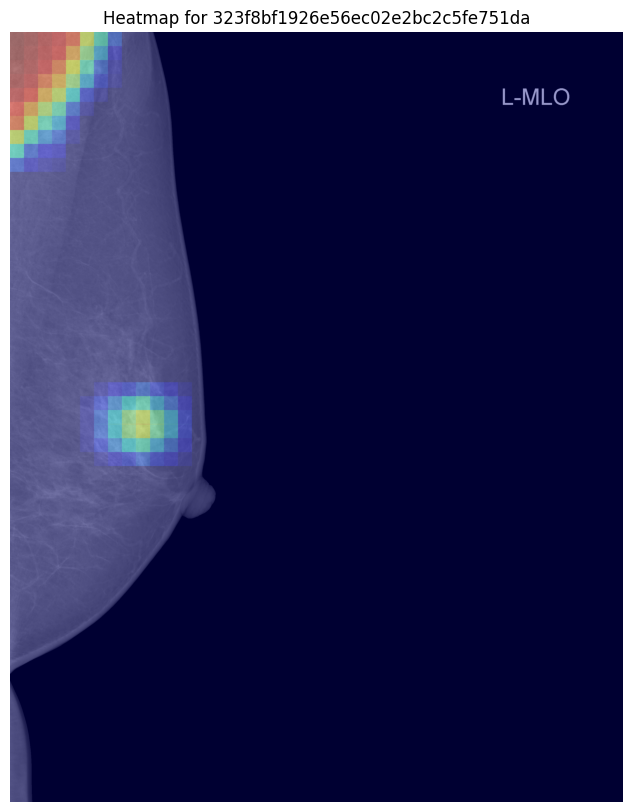

In [ ]:

patch_size = CONFIG["img_size"][0:2]
stride = 64 # Lower stride gives higher detail heatmap, but need more compute time.
threshold = 0.60 # Minimum patch confidence for it to show on the heatmap

# -------------------
# LOAD CSV (must exist already)
# -------------------
df = pd.read_csv("data/finding_annotations.csv")
df = df[['image_id','finding_categories','xmin','ymin','xmax','ymax']]

# -------------------
# BUILD IMAGE INDEX
# -------------------
image_index, z = build_image_index(
    image_folder=image_folder,
    zip_path=zip_path,
    load_from_zip=Load_from_ZIP
)

# -------------------
# LOAD MODEL
# -------------------
model_path = get_model_path(CONFIG)
print("Loading model from:", model_path)
model = load_model(model_path)

# -------------------
# HEATMAP GENERATION
# -------------------
def generate_heatmap(model, img):
    h, w = img.shape
    heatmap = np.zeros((h, w))
    counts = np.zeros((h, w))

    for y in range(0, h - patch_size[0] + 1, stride):
        for x in range(0, w - patch_size[1] + 1, stride):

            if Multi_scale_patch:
                p_small, p_large = extract_multiscale_patch(img, x, y, patch_size[0])

                p_small = np.expand_dims(p_small, axis=(0, -1))
                p_large = np.expand_dims(p_large, axis=(0, -1))

                pred = model.predict([p_small, p_large], verbose=0)[0][0]

            else:
                patch = img[y:y+patch_size[0], x:x+patch_size[1]]
                patch = np.expand_dims(patch, axis=(0, -1))

                pred = model.predict(patch, verbose=0)[0][0]

            pred = 0 if pred < threshold else pred

            heatmap[y:y+patch_size[0], x:x+patch_size[1]] += pred
            counts[y:y+patch_size[0], x:x+patch_size[1]] += 1

    heatmap = heatmap / (counts + 1e-6)

    return heatmap

# -------------------
# VISUALIZATION
# -------------------
def show_heatmap(model, image_id):

    img = load_image(
    image_id=image_id,
    image_index=image_index,
    load_from_zip=Load_from_ZIP,
    zip_file=z
)

    if img is None:
        print("Image not found")
        return

    heatmap = generate_heatmap(model, img)

    plt.figure(figsize=(10,10))
    plt.imshow(img, cmap='gray')

    # overlay heatmap
    plt.imshow(heatmap, cmap='jet', alpha=0.4)

    # draw GT boxes
    rows = df[df['image_id'] == image_id]

    for _, row in rows.iterrows():
        if row['finding_categories'] == "['Mass']" and not np.isnan(row['xmin']):
            x = row['xmin']
            y = row['ymin']
            w = row['xmax'] - row['xmin']
            h = row['ymax'] - row['ymin']

            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2,
                edgecolor='lime',
                facecolor='none'
            )
            plt.gca().add_patch(rect)

    plt.title(f"Heatmap for {image_id}")
    plt.axis('off')
    plt.show()

def get_random_mass_image_id(df, image_index):

    valid_ids = set(image_index.keys())

    mass_df = df[
        (df['finding_categories'] == "['Mass']") &
        (~df['xmin'].isna()) &
        (df['image_id'].isin(valid_ids))
    ]

    if len(mass_df) == 0:
        print("No Mass images found")
        return None

    image_ids = mass_df['image_id'].unique()
    return np.random.choice(image_ids)

def get_random_no_mass_image_id(df, image_index):

    valid_ids = set(image_index.keys())

    grouped = df.groupby('image_id')

    no_mass_ids = []

    for image_id, group in grouped:

        if image_id not in valid_ids:
            continue

        # no bounding boxes → true negative
        if group['xmin'].isna().all():
            no_mass_ids.append(image_id)

    if len(no_mass_ids) == 0:
        print("No 'No Finding' images found")
        return None

    return np.random.choice(no_mass_ids)
# -------------------
# RUN
# -------------------

mass_id = get_random_mass_image_id(df, image_index)
no_mass_id = get_random_no_mass_image_id(df, image_index)

#mass_id = "13eaf76f8ddd04c74b0215255afbb2e3" overwrite to search (can be of any lable)

if mass_id is not None:
    print("\n--- MASS IMAGE ---")
    print("Selected image:", mass_id)
    show_heatmap(model, mass_id)

if no_mass_id is not None:
    print("\n--- NO MASS IMAGE ---")
    print("Selected image:", no_mass_id)
    show_heatmap(model, no_mass_id)